In [1]:
!pip install ultralytics roboflow -q
print("Done")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.3 MB/s eta 0:00:00
Done


In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
!nvidia-smi

CUDA available: False
GPU: None
/bin/bash: line 1: nvidia-smi: command not found


In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="bYq3NezAXyTe3UWGCS10")
project = rf.workspace("malaika-taqveem-p4nms").project("report-0jp5y-byimp")
version = project.version(2)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 88.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Report-2 in yolov8:: 100%|██████████| 1799/1799 [00:00<00:00, 3647.20it/s]


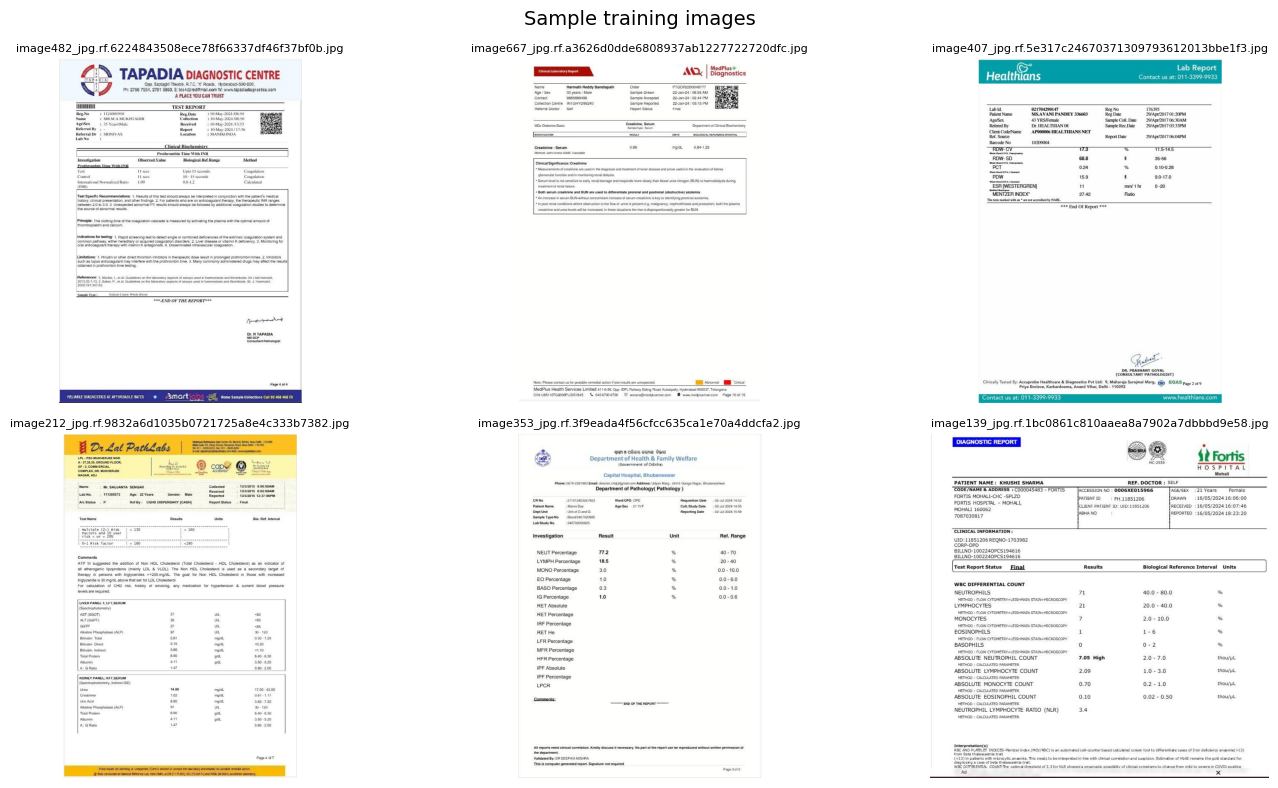

Total training images: 717


In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

train_img_dir = Path(dataset.location) / "train" / "images"
images = list(train_img_dir.glob("*.jpg"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, img_path in zip(axes.flatten(), images):
    img = mpimg.imread(str(img_path))
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

plt.suptitle("Sample training images", fontsize=14)
plt.tight_layout()
plt.show()
print(f"Total training images: {len(list(train_img_dir.glob('*.jpg')))}")

In [5]:
!pip install ultralytics
from ultralytics import YOLO

# Load YOLOv8 nano — smallest model, trains fast, good for small datasets
model = YOLO('yolov8n.pt')

results = model.train(
    data=dataset.location + "/data.yaml",
    epochs=80,
    imgsz=640,
    batch=16,
    name='medscan_yolo_v1',
    project='/content/runs',
    patience=15,        # stop early if val loss stops improving
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,
    mosaic=1.0,         # data augmentation — helps with small datasets
    flipud=0.1,
    fliplr=0.5,
    degrees=5.0,        # slight rotation augmentation for reports
    device=0,
    verbose=True
)

print("Training complete!")
print(f"Best model saved at: {results.save_dir}")

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Report-2/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=medscan_yolo_v1-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pati

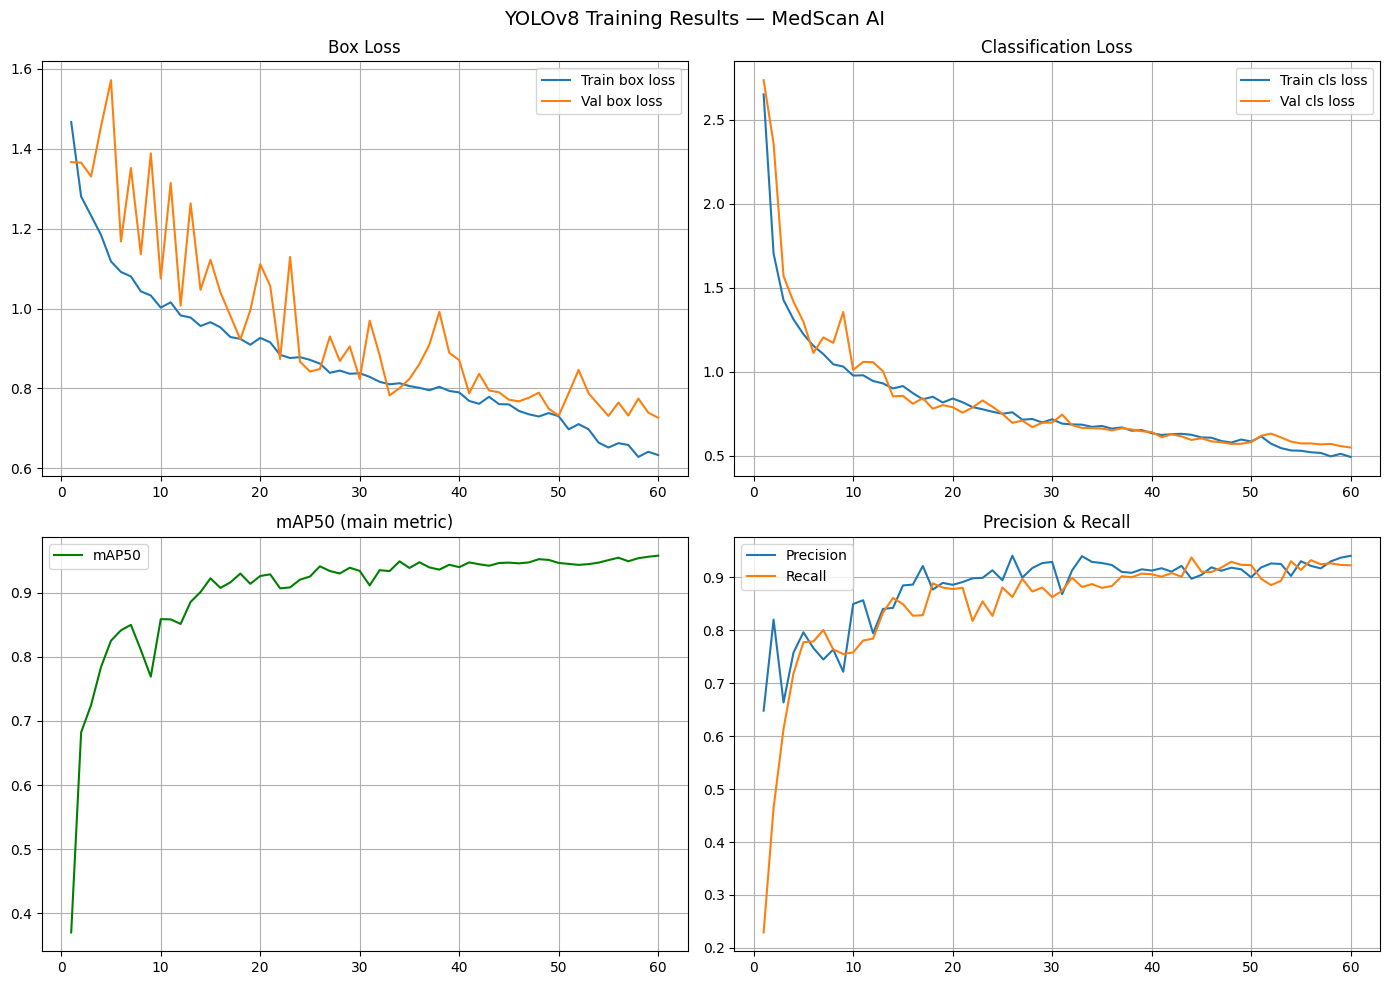


Final metrics:
  mAP50:     0.9580
  Precision: 0.9403
  Recall:    0.9223


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

results_csv = Path('/content/runs/medscan_yolo_v1/results.csv')
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(df['epoch'], df['train/box_loss'], label='Train box loss')
axes[0,0].plot(df['epoch'], df['val/box_loss'],   label='Val box loss')
axes[0,0].set_title('Box Loss'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(df['epoch'], df['train/cls_loss'], label='Train cls loss')
axes[0,1].plot(df['epoch'], df['val/cls_loss'],   label='Val cls loss')
axes[0,1].set_title('Classification Loss'); axes[0,1].legend(); axes[0,1].grid(True)

axes[1,0].plot(df['epoch'], df['metrics/mAP50(B)'], color='green', label='mAP50')
axes[1,0].set_title('mAP50 (main metric)'); axes[1,0].legend(); axes[1,0].grid(True)

axes[1,1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
axes[1,1].plot(df['epoch'], df['metrics/recall(B)'],    label='Recall')
axes[1,1].set_title('Precision & Recall'); axes[1,1].legend(); axes[1,1].grid(True)

plt.suptitle('YOLOv8 Training Results — MedScan AI', fontsize=14)
plt.tight_layout()
plt.show()

final = df.iloc[-1]
print(f"\nFinal metrics:")
print(f"  mAP50:     {final['metrics/mAP50(B)']:.4f}")
print(f"  Precision: {final['metrics/precision(B)']:.4f}")
print(f"  Recall:    {final['metrics/recall(B)']:.4f}")

In [7]:
best_model = YOLO('/content/runs/medscan_yolo_v1/weights/best.pt')

metrics = best_model.val(
    data=dataset.location + "/data.yaml",
    split='test'
)

print("\nValidation Results:")
print(f"  mAP50:       {metrics.box.map50:.4f}")
print(f"  mAP50-95:    {metrics.box.map:.4f}")
print(f"  Precision:   {metrics.box.mp:.4f}")
print(f"  Recall:      {metrics.box.mr:.4f}")
print(f"\nPer-class mAP50:")
for i, name in best_model.names.items():
    print(f"  {name}: {metrics.box.ap50[i]:.4f}")

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1552.1±729.7 MB/s, size: 51.0 KB)
val: Scanning /content/Report-2/test/labels... 90 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 90/90 2.1Kit/s 0.0s
val: New cache created: /content/Report-2/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 7, len(boxes) = 465. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.3it/s 4.6s
                   all         90        465      0.895      0.916      0.937      0.743
              lab_name         76         76      0.899      0.933      0.961      0.66


image 1/90 /content/Report-2/test/images/image009_jpg.rf.ce15cb54e13367bbe164c2625a8f3e75.jpg: 640x448 1 lab_name, 1 patient_personal_details, 1 report_authorization, 1 report_logo, 44.1ms
image 2/90 /content/Report-2/test/images/image029_jpg.rf.96a1a45b555fffb55d0defef43ca3f4e.jpg: 640x480 1 medical_report, 1 patient_personal_details, 1 patient_report_details, 1 report_logo, 41.7ms
image 3/90 /content/Report-2/test/images/image033_jpg.rf.34365d18ceb0559fae2d0cca5d117e88.jpg: 640x480 1 lab_name, 1 patient_personal_details, 1 patient_report_details, 6.5ms
image 4/90 /content/Report-2/test/images/image039_jpg.rf.caa7a0c14c65bc066e88f58f87aa23a4.jpg: 640x480 2 lab_names, 2 medical_reports, 2 patient_personal_detailss, 1 patient_report_details, 1 report_authorization, 1 report_logo, 6.1ms
image 5/90 /content/Report-2/test/images/image041_jpg.rf.08975a9c028dfe720a4fd82c6fa7de10.jpg: 640x480 1 lab_name, 1 medical_report, 1 patient_personal_details, 1 patient_report_details, 6.0ms
image 6/90

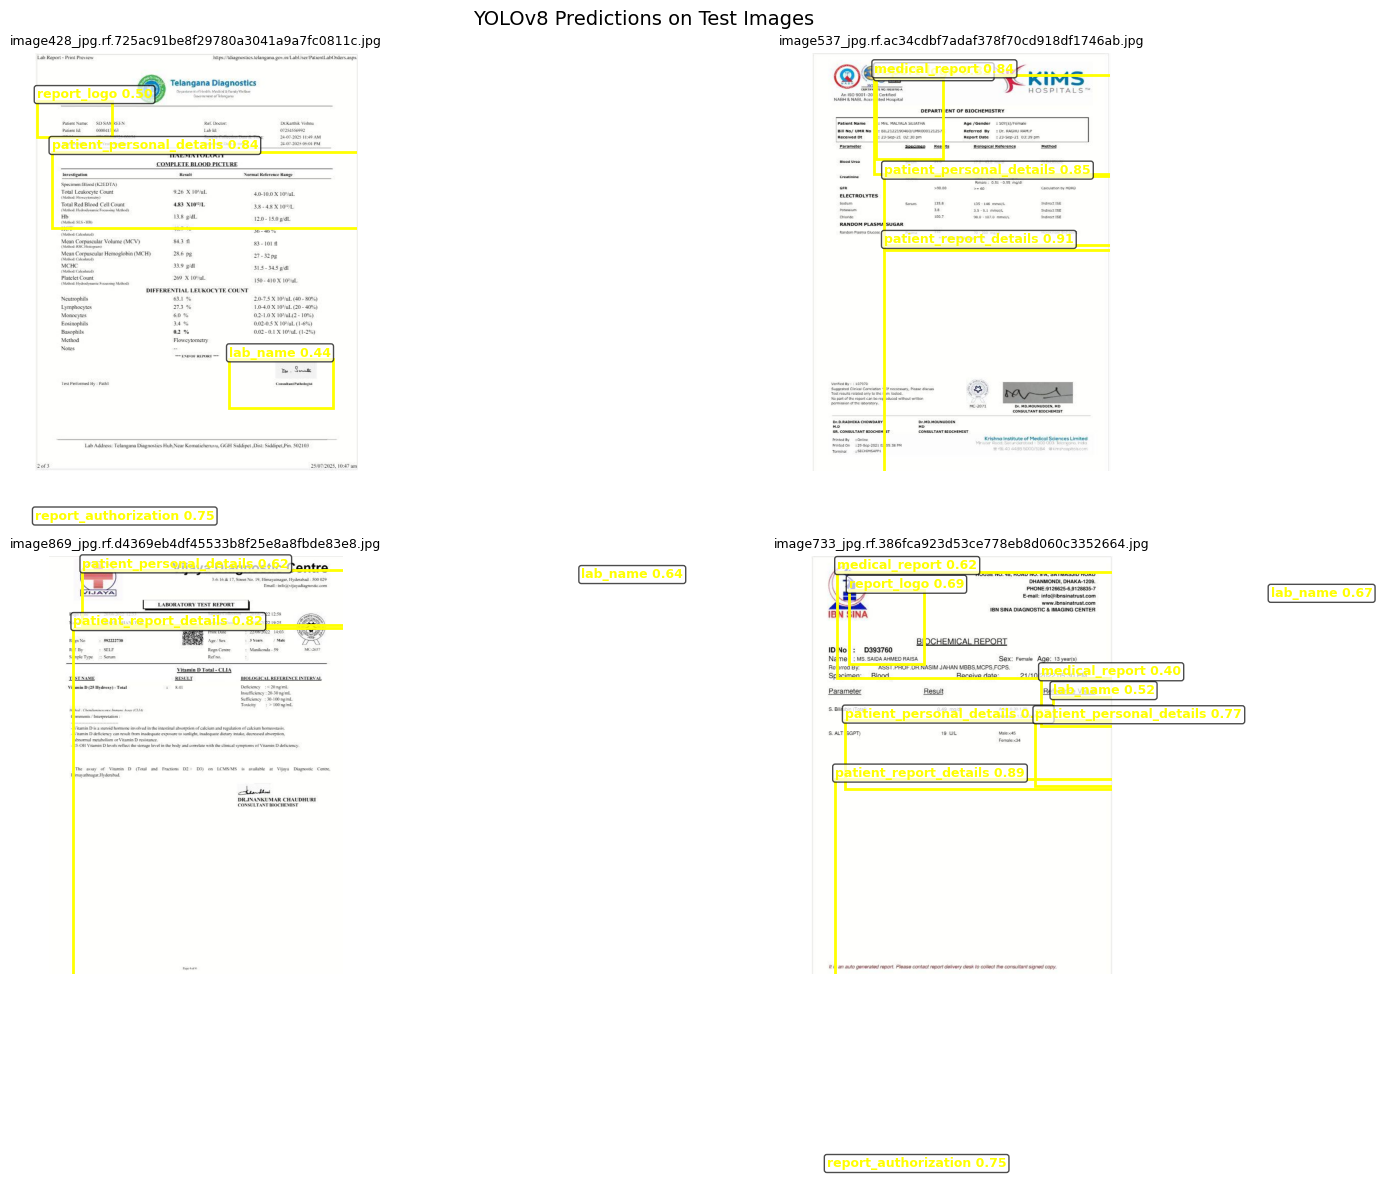

In [8]:
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

test_dir = Path(dataset.location) / "test" / "images"
test_images = list(test_dir.glob("*.jpg"))[:4]

results = best_model.predict(
    source=str(test_dir),
    conf=0.4,
    save=True,
    save_dir='/content/predictions'
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = {'findings': 'red', 'vitals': 'blue', 'header': 'green'}

for ax, (result, img_path) in zip(axes.flatten(), zip(results[:4], test_images)):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)

    for box in result.boxes:
        cls_name = best_model.names[int(box.cls)]
        conf = float(box.conf)
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        color = colors.get(cls_name, 'yellow')

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"{cls_name} {conf:.2f}",
                color=color, fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

    ax.set_title(img_path.name, fontsize=9)
    ax.axis('off')

plt.suptitle('YOLOv8 Predictions on Test Images', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
from google.colab import files
import shutil

# Download best.pt
files.download('/content/runs/medscan_yolo_v1/weights/best.pt')

# Also download last.pt as backup
files.download('/content/runs/medscan_yolo_v1/weights/last.pt')

print("Downloaded best.pt and last.pt")
print("Place best.pt in: models/yolo/best.pt in your VS Code project")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded best.pt and last.pt
Place best.pt in: models/yolo/best.pt in your VS Code project


In [12]:
!zip -r predictions.zip predictions

  adding: predictions/ (stored 0%)
  adding: predictions/image428_jpg.rf.725ac91be8f29780a3041a9a7fc0811c.jpg (deflated 16%)
  adding: predictions/image537_jpg.rf.ac34cdbf7adaf378f70cd918df1746ab.jpg (deflated 17%)
  adding: predictions/image869_jpg.rf.d4369eb4df45533b8f25e8a8fbde83e8.jpg (deflated 12%)
  adding: predictions/image733_jpg.rf.386fca923d53ce778eb8d060c3352664.jpg (deflated 21%)
  adding: predictions/image096_jpg.rf.740d66bee6f3e9f0ffa47e71e8f13cb0.jpg (deflated 13%)
  adding: predictions/image624_jpg.rf.aa2274a7bd955cae8dc20a3057a258f2.jpg (deflated 12%)
  adding: predictions/image792_jpg.rf.54f298b2728a94d084989f13f97346e8.jpg (deflated 19%)
  adding: predictions/image520_jpg.rf.63c83a798a07c3d8b51bc729b0e01c06.jpg (deflated 15%)
  adding: predictions/image350_jpg.rf.406f26e0c08c3aa935ee90f405d1a3a1.jpg (deflated 24%)
  adding: predictions/image398_jpg.rf.8996d7b7503d02767a9795f0496b9a45.jpg (deflated 16%)
  adding: predictions/image816_jpg.rf.2049e6074f242c2507d23967d0f

In [13]:
from google.colab import files

files.download('predictions.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
!zip -r Report-2.zip Report-2

  adding: Report-2/ (stored 0%)
  adding: Report-2/test/ (stored 0%)
  adding: Report-2/test/labels.cache (deflated 57%)
  adding: Report-2/test/images/ (stored 0%)
  adding: Report-2/test/images/image428_jpg.rf.725ac91be8f29780a3041a9a7fc0811c.jpg (deflated 17%)
  adding: Report-2/test/images/image537_jpg.rf.ac34cdbf7adaf378f70cd918df1746ab.jpg (deflated 19%)
  adding: Report-2/test/images/image869_jpg.rf.d4369eb4df45533b8f25e8a8fbde83e8.jpg (deflated 15%)
  adding: Report-2/test/images/image733_jpg.rf.386fca923d53ce778eb8d060c3352664.jpg (deflated 23%)
  adding: Report-2/test/images/image096_jpg.rf.740d66bee6f3e9f0ffa47e71e8f13cb0.jpg (deflated 19%)
  adding: Report-2/test/images/image624_jpg.rf.aa2274a7bd955cae8dc20a3057a258f2.jpg (deflated 12%)
  adding: Report-2/test/images/image792_jpg.rf.54f298b2728a94d084989f13f97346e8.jpg (deflated 27%)
  adding: Report-2/test/images/image520_jpg.rf.63c83a798a07c3d8b51bc729b0e01c06.jpg (deflated 16%)
  adding: Report-2/test/images/image350_jpg

In [15]:
from google.colab import files

files.download("Report-2.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>